# Dinâmica 02 - Aprendizado por Reforço (Tabelas Q)
**Unidade Curricular:** Inteligência Artificial  
**Câmpus:** Chapecó  
**Docente:** Dra. Lara Popov Zambiasi Bazzi Oberderfer  

---
## 🎯 Objetivo
Desenvolver um agente inteligente capaz de navegar em um ambiente de grade (grid world), aprender a localizar um passageiro e entregá-lo no destino utilizando o algoritmo **Q-Learning**.
Ambiente Taxi: https://gymnasium.farama.org/environments/toy_text/taxi/

In [1]:
# = : ================================================================
# 1. PREPARAÇÃO DO AMBIENTE
# =================================================================
# Instalação das dependências do Gymnasium para ambientes de texto
!pip install gymnasium[toy_text] > /dev/null 2>&1

import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
from time import sleep

# Inicialização do ambiente Taxi-v3
# O modo 'ansi' permite capturar o mapa como texto para a animação
env = gym.make("Taxi-v3", render_mode="ansi")

print(f"Espaço de Estados: {env.observation_space.n} (Combinações de posições)")
print(f"Espaço de Ações: {env.action_space.n} (N, S, L, O, Pickup, Dropoff)")

Espaço de Estados: 500 (Combinações de posições)
Espaço de Ações: 6 (N, S, L, O, Pickup, Dropoff)


### 🧠 Sprint 1: Treinamento da Q-Table
Nesta etapa, o agente preencherá uma matriz de conhecimento (Estados x Ações) através da **Equação de Bellman**.
O objetivo é que o agente aprenda quais ações maximizam a recompensa acumulada em cada posição do mapa.

Iniciando treinamento do TaxiDriver... Por favor, aguarde.
Progresso: Episódio 500/2000
Progresso: Episódio 1000/2000
Progresso: Episódio 1500/2000
Progresso: Episódio 2000/2000

Treinamento concluído!


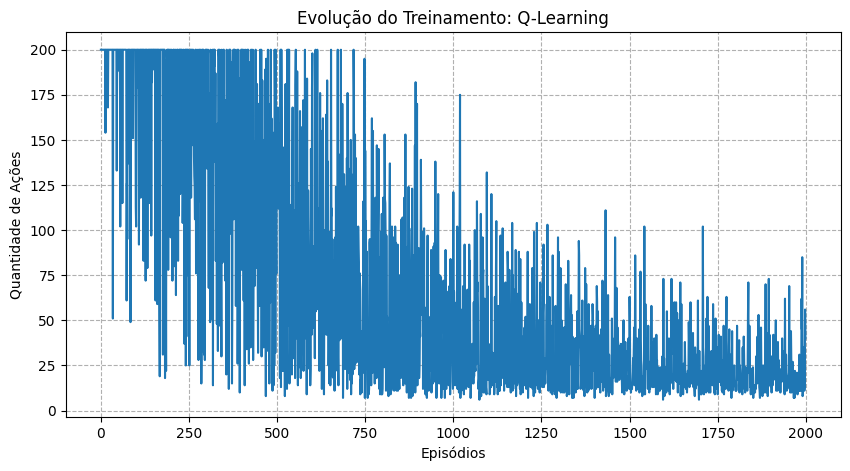

In [2]:
# Hiperparâmetros de Aprendizado
alpha = 0.1    # Taxa de aprendizado
gamma = 0.6    # Fator de desconto (importância do futuro)
epsilon = 0.1  # Probabilidade de exploração (ações aleatórias)
episodios = 2000

# Inicialização da Q-Table com zeros
q_table = np.zeros([env.observation_space.n, env.action_space.n])

history = []

print("Iniciando treinamento do TaxiDriver... Por favor, aguarde.")

for i in range(1, episodios + 1):
    state, info = env.reset()
    done = False
    passos = 0

    while not done:
        # Estratégia Epsilon-Greedy (Exploração vs Explotação)
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # --- ATUALIZAÇÃO DA Q-TABLE ---
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])

        # Fórmula do Q-Learning
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        state = next_state
        passos += 1

    history.append(passos)
    if i % 500 == 0:
        print(f"Progresso: Episódio {i}/{episodios}")

print("\nTreinamento concluído!")

# Gráfico de Convergência
plt.figure(figsize=(10,5))
plt.plot(history)
plt.title('Evolução do Treinamento: Q-Learning')
plt.xlabel('Episódios')
plt.ylabel('Quantidade de Ações')
plt.grid(True, linestyle='--')
plt.show()

### 🚖 Sprint 2: Teste do Agente Treinado
Agora, vamos observar o "cérebro" (Q-Table) em ação. O agente usará apenas o conhecimento adquirido (sem ações aleatórias) para completar a tarefa.

In [3]:
def visualizar_agente(env, q_table):
    state, info = env.reset()
    done = False
    passos = 0

    while not done:
        # O agente escolhe sempre a melhor ação da tabela (Explotação Pura)
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        clear_output(wait=True)
        print(env.render())
        print(f"\nPasso: {passos + 1}")
        print(f"Recompensa da ação: {reward}")

        sleep(0.4) # Velocidade para observação dos alunos
        passos += 1

    print("\n✅ Objetivo alcançado!")

# Execução da visualização
visualizar_agente(env, q_table)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)


Passo: 200
Recompensa da ação: -1

✅ Objetivo alcançado!


# 📝 Ficha de Análise: Dinâmica 02

### Questões Técnicas:

1. **Convergência:** Observe o gráfico gerado no Sprint 1. O que a queda na linha de "Quantidade de Ações" indica sobre o comportamento do agente?
2. **Penalidades:** O que acontece com os valores na Q-Table quando o agente tenta deixar o passageiro em um local errado (Dropoff ilegal)?
3. **Exploração:** Se definíssemos o `epsilon = 0` desde o primeiro episódio, o agente conseguiria aprender a rota ótima? Por quê?
4. **Memória:** Diferente do Desafio 01 (Regressão/Classificação), onde o modelo aprendia padrões em dados estáticos, como o agente do Taxi "aprende" a física do ambiente?